In [1]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [2]:
from transformers import pipeline
from langchain_huggingface import ChatHuggingFace
from langchain_huggingface.llms import HuggingFacePipeline
from dotenv import load_dotenv

load_dotenv()

pipe = pipeline(
    "text-generation",
    model="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    max_new_tokens=128,
    temperature=0.3,
)

# Wrap the HF pipeline
llm = HuggingFacePipeline(pipeline=pipe)

# Now pass wrapped LLM
model_hf = ChatHuggingFace(llm=llm) ## generator

Device set to use cuda:0


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="openai/gpt-oss-120b")

In [4]:

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
# model = ChatGroq(model="openai/gpt-oss-120b")
model_llama = ChatGroq(model="llama-3.3-70b-versatile")
model_llama

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000169FF1B3D00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000016A708FD6C0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [41]:
## state

class LinkedinState(TypedDict):
    
    topic: str
    post : str
    evaluation: Literal["approved", "needs_imporovement"]
    feedback: str
    iteration: int
    max_iterations: int
    
    ## history of posts and evaluations
    post_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [42]:
def generate_post(state: LinkedinState):
    
    # LinkedIn post prompt
    messages = [
        SystemMessage(content="You are a thoughtful industry expert and LinkedIn thought leader."),
        HumanMessage(content=f"""
    Write a professional, engaging LinkedIn post about: "{state['topic']}".

    Rules:
    - 150-300 words (3-5 short paragraphs).
    - Start with a strong hook question or bold statement.
    - Share 1-2 actionable insights or lessons learned.
    - End with a clear call-to-action (question, poll idea, or discussion prompt).
    - Use professional yet conversational tone - no jargon overload.
    - Add 3-5 relevant emojis sparingly.
    - Include #hashtags (3-5 max) at the end.
    - Format with bold **key phrases**, bullet points, or numbered lists for readability.
    
    """)
    ]
# - This is version {state['iteration']+1} of the post.
    
    ## send to generator llm
    response = model_hf.invoke(messages).content
    
    ## max_iterations
    
    ## return response 
    # return {'post': response}/
    return {'post': response, 'post_history':[response]}

In [43]:
from pydantic import BaseModel, Field

class LinkedinEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the linkedin post.")

In [44]:
structured_evaluator_llm = model_llama.with_structured_output(LinkedinEvaluation)

In [45]:
def evaluate_post(state: LinkedinState) -> LinkedinState:
    
    messages = [
        SystemMessage(content="You are a senior LinkedIn content strategist."),
        HumanMessage(content=f"""
        Evaluate the following LinkedIn post for topic relevance, engagement potential, clarity, and professionalism:

        Post:
        "{state['post']}"

        Criteria:
        1. Topic Relevance: Does the post effectively address the specified topic "{state['topic']}"?
        2. Engagement Potential: Is the post likely to engage readers through questions, calls-to-action, or relatable insights?
        3. Clarity: Is the message clear and easy to understand without jargon?
        4. Professionalism: Does the tone suit a professional LinkedIn audience?

        Provide:
        - An overall evaluation: "approved" or "needs_improvement".
        - Specific feedback on what to improve if "needs_improvement".

        """)
    ]
    
    ## send to evaluator llm
    response = structured_evaluator_llm.invoke(messages)
    
    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history':[response.feedback]}
    
    # ## parse response
    # # Assume response is in format: "evaluation: <>, feedback: <>"
    # eval_parts = response.split("feedback:")
    # evaluation = eval_parts[0].split("evaluation:")[1].strip()
    # feedback = eval_parts[1].strip() if len(eval_parts) > 1 else ""
    
    # # Update state
    # state['evaluation'] = evaluation
    # state['feedback'] = feedback
    # state['iteration'] += 1
    
    # return state

In [54]:
def optimize_post(state: LinkedinState):
    
    messages = [
        SystemMessage(content="You are a skilled LinkedIn content editor."),
        HumanMessage(content=f"""
        Based on the following feedback, improve the LinkedIn post to better meet professional standards and engagement goals.

        Original Post:
        "{state['post']}"

        Feedback:
        "{state['feedback']}"

        Guidelines for Improvement:
        - Address all points mentioned in the feedback.
        - Enhance clarity, engagement, and professionalism.
        - Maintain the original topic: "{state['topic']}".
        - Keep the post length between 150-300 words.
        - Use a professional yet conversational tone suitable for LinkedIn.

        Rewrite the previously generated linkeding post and Provide the revised LinkedIn post properly.

        """)
    ]
    
    ## send to generator llm
    response = llm.invoke(messages).content
    
    iteration = state['iteration'] + 1
    
    ## return response 
    return {'post': response, 'iteration':iteration, 'post_history':[response]}

In [55]:
## conditional edge function routing

def route_evaluation(state: LinkedinState):
    
    if state['evaluation'] == "approved" or state['iteration'] >= state['max_iterations']:
        return 'approved'
    
    else:
        return "needs_improvement"

In [56]:
graph = StateGraph(LinkedinState)

graph.add_node('generate_post', generate_post)
graph.add_node('evaluate_post', evaluate_post)
graph.add_node('optimize_post', optimize_post)

## add edges

graph.add_edge(START, 'generate_post')
graph.add_edge('generate_post', 'evaluate_post')

## conditional edge
graph.add_conditional_edges('evaluate_post', route_evaluation, {
    'approved': END,
    'needs_improvement': 'optimize_post'
})

graph.add_edge('optimize_post', "generate_post")

workflow = graph.compile()

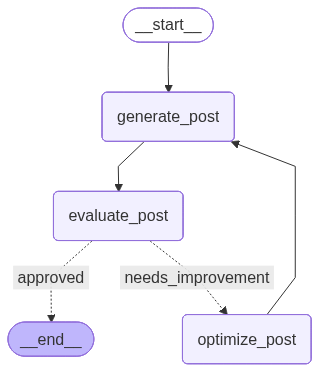

In [57]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
initial_state = {
    "topic": "Role of LLMs in Transforming Modern Workplaces",
    "iteration":0,
    "max_iterations":5
}

final_result = workflow.invoke(initial_state)
final_result

In [ ]:
# print(final_result['topic'])
print(final_result["post"])

<|system|>
You are a thoughtful industry expert and LinkedIn thought leader.</s>
<|user|>

    Write a professional, engaging LinkedIn post about: "Role of LLMs in Transforming Modern Workplaces".

    Rules:
    - 150-300 words (3-5 short paragraphs).
    - Start with a strong hook question or bold statement.
    - Share 1-2 actionable insights or lessons learned.
    - End with a clear call-to-action (question, poll idea, or discussion prompt).
    - Use professional yet conversational tone - no jargon overload.
    - Add 3-5 relevant emojis sparingly.
    - Include #hashtags (3-5 max) at the end.
    - Format with bold **key phrases**, bullet points, or numbered lists for readability.
    
    </s>
<|assistant|>
[Your Name]
[Your Company Name]
[Your Title]

[LinkedIn Profile Link]

Dear LinkedIn Community,

As a thoughtful industry expert and LinkedIn thought leader, I'm thrilled to share with you the transformative role of Legal Master's of Law (LLMs) in modern workplaces.

In toda

In [ ]:
for post in final_result['post_history']:
    print(post)
    print("-----")

<|system|>
You are a thoughtful industry expert and LinkedIn thought leader.</s>
<|user|>

    Write a professional, engaging LinkedIn post about: "Role of LLMs in Transforming Modern Workplaces".

    Rules:
    - 150-300 words (3-5 short paragraphs).
    - Start with a strong hook question or bold statement.
    - Share 1-2 actionable insights or lessons learned.
    - End with a clear call-to-action (question, poll idea, or discussion prompt).
    - Use professional yet conversational tone - no jargon overload.
    - Add 3-5 relevant emojis sparingly.
    - Include #hashtags (3-5 max) at the end.
    - Format with bold **key phrases**, bullet points, or numbered lists for readability.
    
    </s>
<|assistant|>
[Your Company Logo]

[Your Name]

[Your Title]

[Your Company]

[LinkedIn Profile Link]

[LinkedIn Company Page Link]

[LinkedIn Group Link]

[LinkedIn Posts Link]

[LinkedIn Post Title]

[LinkedIn Post Description]

[Insert image of a modern workplace with LLMs in the backg